In [1]:
from sklearn.datasets import fetch_20newsgroups

dataset = fetch_20newsgroups(remove=('headers','footers','quotes'))

documents = dataset.data

print("Total Documents:", len(documents))
print("\nSample Document:\n")
print(documents[0][:500])

Total Documents: 11314

Sample Document:

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


In [2]:
print(dataset.target_names)

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


DATA PREPROCESSING

In [3]:
import nltk
import re

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
custom_words = {
    'know','think','said','like','really',
    'people','make','going','thing','want',
    'does','did','just','good','right'
}

stop_words = stop_words.union(custom_words)
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Computer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Computer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Computer\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Computer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
def is_repeated_char(word):
    return len(set(word)) <= 2

def preprocess(text):

    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if len(word) > 3]
    tokens = [word for word in tokens if not is_repeated_char(word)]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [6]:
processed_docs = [preprocess(doc) for doc in documents]

DTM

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    max_df=0.85,
    min_df=15,
    stop_words='english',
    token_pattern=r'\b[a-zA-Z]{4,15}\b'
)

count_matrix = count_vectorizer.fit_transform(processed_docs)

print("DTM Shape:", count_matrix.shape)

DTM Shape: (11314, 5564)


In [8]:
sum_words = count_matrix.sum(axis=0)
words = count_vectorizer.get_feature_names_out()

word_freq = [(word, int(sum_words[0, idx])) for idx, word in enumerate(words)]
word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)

print(word_freq[:10])

[('dont', 3862), ('time', 3478), ('year', 2698), ('file', 2520), ('problem', 2294), ('work', 2164), ('need', 1964), ('program', 1898), ('used', 1865), ('window', 1830)]


LDA MODEL

In [9]:
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(
    n_components=30,      # 30 topics
    random_state=42,
    learning_method='batch'
)

lda_model.fit(count_matrix)

print("LDA Model Trained Successfully")

LDA Model Trained Successfully


top 10 words

In [10]:
words = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic {topic_idx + 1}:")
    top_words = [words[i] for i in topic.argsort()[-10:]]
    print(top_words)


Topic 1:
['catholic', 'question', 'dont', 'religious', 'believe', 'atheist', 'belief', 'religion', 'church', 'christian']

Topic 2:
['polygon', 'warning', 'dont', 'main', 'wave', 'need', 'stuff', 'heard', 'tank', 'deleted']

Topic 3:
['application', 'server', 'code', 'display', 'widget', 'version', 'available', 'program', 'image', 'file']

Topic 4:
['money', 'program', 'thats', 'year', 'work', 'time', 'question', 'dont', 'group', 'president']

Topic 5:
['dont', 'type', 'work', 'quality', 'font', 'picture', 'image', 'jpeg', 'color', 'problem']

Topic 6:
['machine', 'program', 'using', 'memory', 'file', 'work', 'driver', 'card', 'problem', 'window']

Topic 7:
['pittsburgh', 'flyer', 'chicago', 'second', 'power', 'game', 'shot', 'goal', 'period', 'play']

Topic 8:
['secure', 'technology', 'phone', 'algorithm', 'privacy', 'security', 'government', 'clipper', 'chip', 'encryption']

Topic 9:
['work', 'water', 'cover', 'used', 'mile', 'tire', 'high', 'speed', 'power', 'engine']

Topic 10:
['

topic probability per document

In [11]:
doc_topic_matrix = lda_model.transform(count_matrix)

print("Document-Topic Matrix Shape:", doc_topic_matrix.shape)

Document-Topic Matrix Shape: (11314, 30)


dominant topic

In [12]:
import numpy as np
dominant_topic=np.argmax(doc_topic_matrix,axis=1)

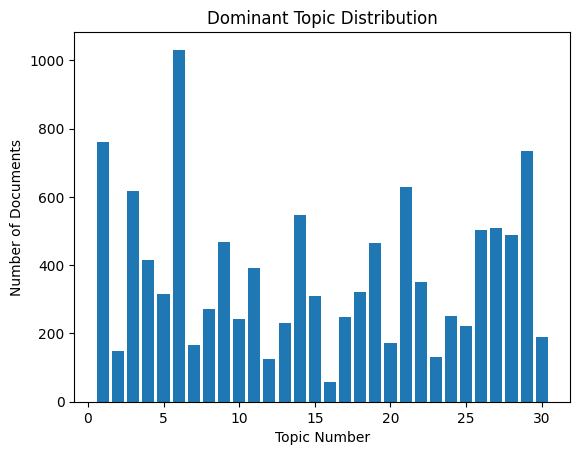

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Count documents per topic
topic_counts = np.bincount(dominant_topic)

plt.figure()
plt.bar(range(1, len(topic_counts)+1), topic_counts)
plt.xlabel("Topic Number")
plt.ylabel("Number of Documents")
plt.title("Dominant Topic Distribution")
plt.show()

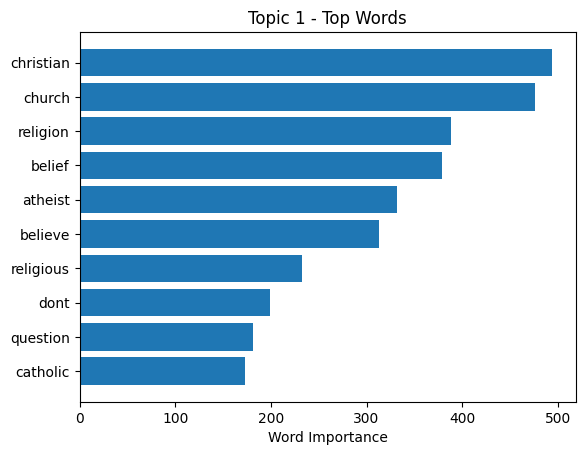

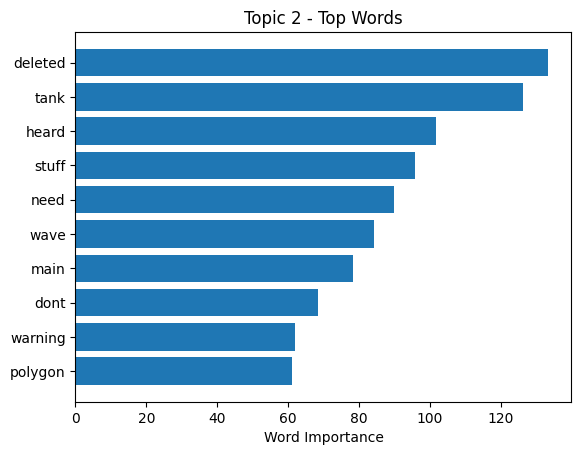

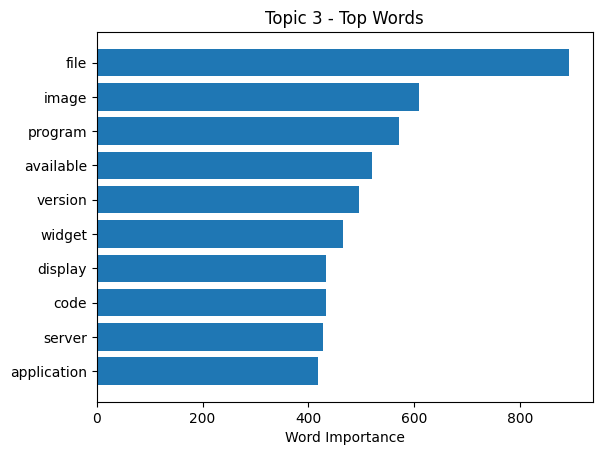

In [14]:
import matplotlib.pyplot as plt
import numpy as np

words = count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda_model.components_[:3]):

    # Get top 10 words
    top_indices = topic.argsort()[-10:]
    top_words = words[top_indices]
    top_values = topic[top_indices]

    plt.figure()
    plt.barh(top_words, top_values)
    plt.xlabel("Word Importance")
    plt.title(f"Topic {topic_idx + 1} - Top Words")
    plt.show()

In [15]:
import pandas as pd

df_dominant = pd.DataFrame({
    "Document_Number": range(len(dominant_topic)),
    "Dominant_Topic": dominant_topic
})

print(df_dominant.head())

   Document_Number  Dominant_Topic
0                0               8
1                1              20
2                2              20
3                3               9
4                4              28


TF-IDF MATRIX

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.85,
    min_df=15,
    stop_words='english'
)

tfidf_matrix = tfidf_vectorizer.fit_transform(processed_docs)

print("TF-IDF Shape:", tfidf_matrix.shape)

TF-IDF Shape: (11314, 5656)


NMF

In [17]:
from sklearn.decomposition import NMF

nmf_model = NMF(n_components=30, random_state=42)
nmf_model.fit(tfidf_matrix)

print("NMF trained successfully")

NMF trained successfully


extract top words

In [18]:
words = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):
    print(f"\nNMF Topic {topic_idx + 1}:")
    top_words = [words[i] for i in topic.argsort()[-10:]]
    print(top_words)


NMF Topic 1:
['police', 'case', 'criminal', 'federal', 'gun', 'weapon', 'right', 'crime', 'state', 'government']

NMF Topic 2:
['desktop', 'display', 'font', 'using', 'microsoft', 'screen', 'running', 'application', 'manager', 'window']

NMF Topic 3:
['tape', 'switch', 'internal', 'controller', 'jumper', 'boot', 'floppy', 'hard', 'disk', 'drive']

NMF Topic 4:
['point', 'ranger', 'better', 'best', 'season', 'hockey', 'league', 'play', 'player', 'team']

NMF Topic 5:
['wondering', 'appreciate', 'help', 'appreciated', 'information', 'anybody', 'info', 'looking', 'advance', 'thanks']

NMF Topic 6:
['mode', 'vesa', 'controller', 'cache', 'memory', 'nubus', 'graphic', 'slot', 'video', 'card']

NMF Topic 7:
['soon', 'bank', 'surrender', 'skepticism', 'intellect', 'shameful', 'gordon', 'njxp', 'chastity', 'gebcadredslpittedu']

NMF Topic 8:
['security', 'secret', 'secure', 'phone', 'escrow', 'algorithm', 'key', 'encryption', 'clipper', 'chip']

NMF Topic 9:
['byte', 'read', 'utility', 'image

document topic probability

In [19]:
nmf_doc_topic = nmf_model.transform(tfidf_matrix)

print(nmf_doc_topic.shape)

(11314, 30)


dominant topic

In [20]:
import numpy as np

nmf_dominant_topic = np.argmax(nmf_doc_topic, axis=1) + 1

print(nmf_dominant_topic[:10])

[26  6  5 30 29 11 28 24 22  9]


In [21]:
import pandas as pd

nmf_topic_weight = np.max(nmf_doc_topic, axis=1)

df_results = pd.DataFrame({
    "Document_No": range(len(nmf_dominant_topic)),
    "Dominant_Topic": nmf_dominant_topic,
    "Topic_Weight": nmf_topic_weight
})

df_results.head()

,Document_No,Dominant_Topic,Topic_Weight
0,0,26,0.062286
1,1,6,0.041185
2,2,5,0.049168
3,3,30,0.196653
4,4,29,0.041015


COHERENCE SCORE

In [22]:
import sys
!{sys.executable} -m pip install gensim


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Tokenized documents (must be list of word lists)
texts = [doc.split() for doc in processed_docs]

dictionary = Dictionary(texts)

extracting top words

In [24]:
def get_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic in model.components_:
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics.append(top_words)
    return topics

In [25]:
lda_topics = get_topics(lda_model, count_vectorizer.get_feature_names_out())

In [26]:
nmf_topics = get_topics(nmf_model, tfidf_vectorizer.get_feature_names_out())

In [27]:
coherence_lda = CoherenceModel(
    topics=lda_topics,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

print("LDA Coherence:", coherence_lda)

LDA Coherence: 0.6015238678761983


In [28]:
coherence_nmf = CoherenceModel(
    topics=nmf_topics,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

print("NMF Coherence:", coherence_nmf)

NMF Coherence: 0.69553625381472


In [29]:
from sklearn.decomposition import NMF
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

texts = [doc.split() for doc in processed_docs]

topic_range = range(5, 31, 5)
nmf_coherence_scores = []

for num_topics in topic_range:

    nmf_model = NMF(n_components=num_topics, random_state=42)
    nmf_model.fit(tfidf_matrix)

    topics = []
    feature_names = tfidf_vectorizer.get_feature_names_out()

    for topic in nmf_model.components_:
        top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
        topics.append(top_words)

    coherence_model = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    nmf_coherence_scores.append(coherence_model.get_coherence())

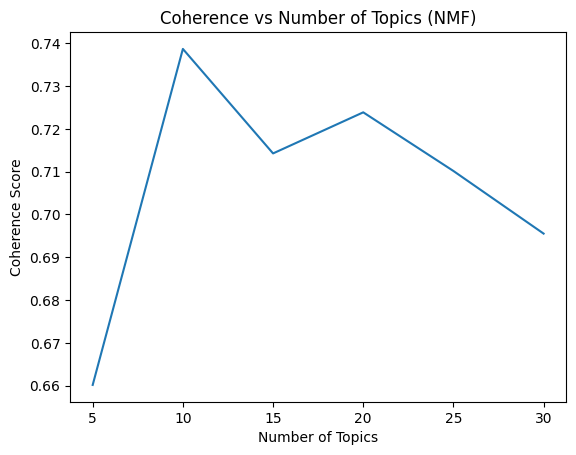

In [30]:
plt.plot(topic_range, nmf_coherence_scores)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Coherence vs Number of Topics (NMF)")
plt.show()

In [31]:
from sklearn.decomposition import LatentDirichletAllocation

lda_coherence_scores = []

for num_topics in topic_range:

    lda_model = LatentDirichletAllocation(
        n_components=num_topics,
        random_state=42
    )

    lda_model.fit(count_matrix)

    topics = []
    feature_names = count_vectorizer.get_feature_names_out()

    for topic in lda_model.components_:
        top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
        topics.append(top_words)

    coherence_model = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    lda_coherence_scores.append(coherence_model.get_coherence())

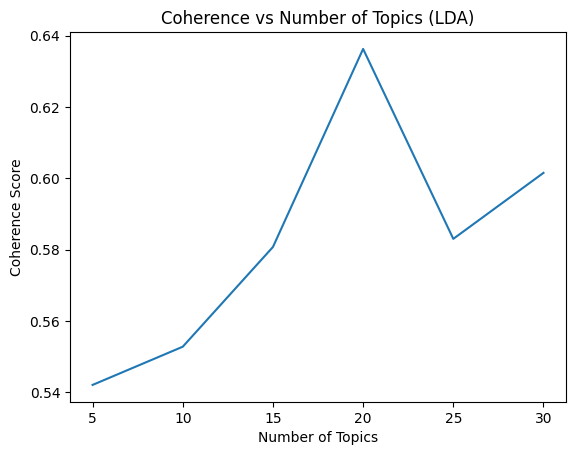

In [32]:
plt.plot(topic_range, lda_coherence_scores)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Coherence vs Number of Topics (LDA)")
plt.show()

LABELLING

In [33]:
topic_labels = {
    1: "Crime and Gun Control",
    2: "Windows/Desktop Applications",
    3: "Hard Disk and Storage Devices",
    4: "Hockey Discussion",
    5: "General Help Requests",
    6: "Graphics Hardware and Video Cards",
    7: "Random/Noisy Discussion",
    8: "Cryptography and Encryption",
    9: "File and Disk Utilities",
    10: "Armenia-Azerbaijan Conflict",
    11: "General Discussion Posts",
    12: "Product Sale and Marketplace",
    13: "Motorcycles and Riding",
    14: "Software Troubleshooting",
    15: "Christianity and Religion",
    16: "Device Drivers and Downloads",
    17: "Casual Conversation",
    18: "Baseball and Sports News",
    19: "Printing and Fonts",
    20: "Middle East Conflict (Israel-Palestine)",
    21: "Apple/Mac Video Hardware",
    22: "Program Errors and Debugging",
    23: "Space and NASA Missions",
    24: "SCSI and Data Interfaces",
    25: "Memory (VRAM/SIMMS) Issues",
    26: "Sports Career and Statistics",
    27: "Modems and Serial Communication",
    28: "Email and Mailing Lists",
    29: "Graphics Software and Source Code",
    30: "Telephone and Communication Services"
}

In [34]:
df_results["Topic_Label"] = df_results["Dominant_Topic"].map(topic_labels)

df_results.head()

,Document_No,Dominant_Topic,Topic_Weight,Topic_Label
0,0,26,0.062286,Sports Career and Statistics
1,1,6,0.041185,Graphics Hardware and Video Cards
2,2,5,0.049168,General Help Requests
3,3,30,0.196653,Telephone and Communication Services
4,4,29,0.041015,Graphics Software and Source Code


In [35]:
broad_category_map = {
    "Crime and Gun Control": "talk.politics.guns",
    "Armenia-Azerbaijan Conflict": "talk.politics.mideast",
    "Middle East Conflict (Israel-Palestine)": "talk.politics.mideast",

    "Christianity and Religion": "soc.religion.christian",
    "Atheism Discussions": "alt.atheism",

    "Graphics Hardware and Video Cards": "comp.graphics",
    "Graphics Software and Source Code": "comp.graphics",

    "Windows/Desktop Applications": "comp.os.ms-windows.misc",
    "Apple/Mac Video Hardware": "comp.sys.mac.hardware",

    "Hard Disk and Storage Devices": "comp.sys.ibm.pc.hardware",
    "Memory (VRAM/SIMMS) Issues": "comp.sys.ibm.pc.hardware",

    "Program Errors and Debugging": "comp.programming",

    "Cryptography and Encryption": "sci.crypt",

    "Space and NASA Missions": "sci.space",

    "Baseball and Sports News": "rec.sport.baseball",
    "Hockey Discussion": "rec.sport.hockey",
    "Sports Career and Statistics": "rec.sport.baseball",

    "Motorcycles and Riding": "rec.motorcycles",

    "Product Sale and Marketplace": "misc.forsale",

    "General Help Requests": "misc.misc",
    "Casual Conversation": "talk.religion.misc",
    "General Discussion Posts": "misc.misc",

    "Modems and Serial Communication": "comp.dcom",
    "Telephone and Communication Services": "comp.dcom",

    "Software Troubleshooting": "comp.os.ms-windows.misc",
    "Device Drivers and Downloads": "comp.sys.ibm.pc.hardware",
    "Printing and Fonts": "comp.graphics",
    "File and Disk Utilities": "comp.sys.ibm.pc.hardware",

    "Random/Noisy Discussion": "misc.misc"
}
broad_category_map["SCSI and Data Interfaces"] = "comp.sys.ibm.pc.hardware"
broad_category_map["Email and Mailing Lists"] = "comp.dcom"

In [36]:
df_results["Broad_Category"] = df_results["Topic_Label"].map(broad_category_map)
df_results.head()

,Document_No,Dominant_Topic,Topic_Weight,Topic_Label,Broad_Category
0,0,26,0.062286,Sports Career and Statistics,rec.sport.baseball
1,1,6,0.041185,Graphics Hardware and Video Cards,comp.graphics
2,2,5,0.049168,General Help Requests,misc.misc
3,3,30,0.196653,Telephone and Communication Services,comp.dcom
4,4,29,0.041015,Graphics Software and Source Code,comp.graphics


In [37]:
df_results["Topic_Label"].nunique()
df_results["Broad_Category"].nunique()
df_results["Broad_Category"].value_counts()

Broad_Category
misc.misc                   1726
comp.sys.ibm.pc.hardware    1250
comp.dcom                   1054
comp.graphics               1023
soc.religion.christian       880
rec.sport.baseball           803
talk.politics.guns           714
talk.religion.misc           695
rec.sport.hockey             541
misc.forsale                 423
sci.crypt                    423
talk.politics.mideast        421
sci.space                    396
comp.os.ms-windows.misc      293
rec.motorcycles              265
comp.programming             234
comp.sys.mac.hardware        173
Name: count, dtype: int64

In [38]:
topic_summary = df_results.groupby("Dominant_Topic").agg({
    "Topic_Label": "first",
    "Broad_Category": "first"
}).reset_index()

topic_summary

,Dominant_Topic,Topic_Label,Broad_Category
0,1,Crime and Gun Control,talk.politics.guns
1,2,Windows/Desktop Applications,comp.os.ms-windows.misc
2,3,Hard Disk and Storage Devices,comp.sys.ibm.pc.hardware
3,4,Hockey Discussion,rec.sport.hockey
4,5,General Help Requests,misc.misc
5,6,Graphics Hardware and Video Cards,comp.graphics
6,7,Random/Noisy Discussion,misc.misc
7,8,Cryptography and Encryption,sci.crypt
8,9,File and Disk Utilities,comp.sys.ibm.pc.hardware
9,10,Armenia-Azerbaijan Conflict,talk.politics.mideast


SENTIMENT ANALYSIS

In [39]:
# Attach original text to topic results
df_results["Original_Text"] = documents

In [40]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df_results["Sentiment_Score"] = df_results["Original_Text"].apply(
    lambda text: sia.polarity_scores(text)["compound"]
)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Computer\AppData\Roaming\nltk_data...


In [41]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_results["Sentiment_Label"] = df_results["Sentiment_Score"].apply(classify_sentiment)

In [42]:
df_results.head()

,Document_No,Dominant_Topic,Topic_Weight,Topic_Label,Broad_Category,Original_Text,Sentiment_Score,Sentiment_Label
0,0,26,0.062286,Sports Career and Statistics,rec.sport.baseball,I was wondering if anyone out there could enli...,0.6249,Positive
1,1,6,0.041185,Graphics Hardware and Video Cards,comp.graphics,A fair number of brave souls who upgraded thei...,0.9468,Positive
2,2,5,0.049168,General Help Requests,misc.misc,"well folks, my mac plus finally gave up the gh...",0.9761,Positive
3,3,30,0.196653,Telephone and Communication Services,comp.dcom,\nDo you have Weitek's address/phone number? ...,0.4215,Positive
4,4,29,0.041015,Graphics Software and Source Code,comp.graphics,"From article <C5owCB.n3p@world.std.com>, by to...",-0.8020,Negative


In [43]:
df_results["Sentiment_Label"].value_counts()

Sentiment_Label
Positive    6894
Negative    3138
Neutral     1282
Name: count, dtype: int64

In [44]:
topic_sentiment = pd.crosstab(
    df_results["Broad_Category"],
    df_results["Sentiment_Label"]
)

topic_sentiment

Sentiment_Label,Negative,Neutral,Positive
Broad_Category,,,
comp.dcom,231,91,732
comp.graphics,183,109,731
comp.os.ms-windows.misc,118,20,155
comp.programming,48,23,163
comp.sys.ibm.pc.hardware,333,116,801
comp.sys.mac.hardware,43,18,112
misc.forsale,57,48,318
misc.misc,519,154,1053
rec.motorcycles,74,33,158


percentage representation

In [45]:
topic_sentiment_percent = pd.crosstab(
    df_results["Broad_Category"],
    df_results["Sentiment_Label"],
    normalize='index'
) * 100

topic_sentiment_percent

Sentiment_Label,Negative,Neutral,Positive
Broad_Category,,,
comp.dcom,21.916509,8.633776,69.449715
comp.graphics,17.888563,10.654936,71.456500
comp.os.ms-windows.misc,40.273038,6.825939,52.901024
comp.programming,20.512821,9.829060,69.658120
comp.sys.ibm.pc.hardware,26.640000,9.280000,64.080000
comp.sys.mac.hardware,24.855491,10.404624,64.739884
misc.forsale,13.475177,11.347518,75.177305
misc.misc,30.069525,8.922364,61.008111
rec.motorcycles,27.924528,12.452830,59.622642


# categories

In [46]:
len(dataset.target_names)

20

In [47]:
len(set(topic_summary["Broad_Category"]))

17

In [48]:
sorted(topic_summary["Broad_Category"].unique())

['comp.dcom',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.programming',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'misc.forsale',
 'misc.misc',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.religion.misc']

In [49]:
sorted(df_results["Broad_Category"].unique())

['comp.dcom',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.programming',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'misc.forsale',
 'misc.misc',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.religion.misc']

In [50]:
mapped_categories = set(topic_summary["Broad_Category"])
present_categories = set(df_results["Broad_Category"])

missing = mapped_categories - present_categories
missing

set()

In [51]:
all_categories = set(dataset.target_names)
present_categories = set(df_results["Broad_Category"].unique())

missing = all_categories - present_categories
missing

{'alt.atheism',
 'comp.windows.x',
 'rec.autos',
 'sci.electronics',
 'sci.med',
 'talk.politics.misc'}

In [52]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

# Reload original dataset (temporary)
newsgroups = fetch_20newsgroups(subset='all')

original_df = pd.DataFrame({
    "Original_Text": newsgroups.data,
    "Original_Category": [newsgroups.target_names[i] for i in newsgroups.target]
})

# Create a temporary merged copy (DO NOT touch df_results)
df_temp = df_results.merge(
    original_df[["Original_Category"]],
    left_on="Document_No",
    right_index=True,
    how="left"
)

# Categories you want to check
check_categories = [
    'alt.atheism',
    'comp.windows.x',
    'rec.autos',
    'sci.electronics',
    'sci.med',
    'talk.politics.misc'
]

# See where they went
result = df_temp[df_temp["Original_Category"].isin(check_categories)] \
    .groupby(["Original_Category", "Broad_Category"]) \
    .size()

print(result)

Original_Category   Broad_Category          
alt.atheism         comp.dcom                   27
                    comp.graphics               47
                    comp.os.ms-windows.misc      9
                    comp.programming             6
                    comp.sys.ibm.pc.hardware    61
                                                ..
talk.politics.misc  sci.space                   16
                    soc.religion.christian      34
                    talk.politics.guns          32
                    talk.politics.mideast       19
                    talk.religion.misc          33
Length: 102, dtype: int64


In [53]:
df_temp[df_temp["Original_Category"].isin(check_categories)] \
    .groupby("Original_Category")["Broad_Category"] \
    .unique()

Original_Category
alt.atheism           [misc.forsale, misc.misc, comp.sys.ibm.pc.hard...
comp.windows.x        [rec.sport.hockey, rec.sport.baseball, misc.mi...
rec.autos             [talk.religion.misc, comp.dcom, rec.sport.base...
sci.electronics       [misc.misc, comp.programming, rec.sport.baseba...
sci.med               [sci.space, talk.politics.mideast, comp.graphi...
talk.politics.misc    [sci.crypt, comp.graphics, comp.sys.ibm.pc.har...
Name: Broad_Category, dtype: object

# graph

<Figure size 1400x800 with 0 Axes>

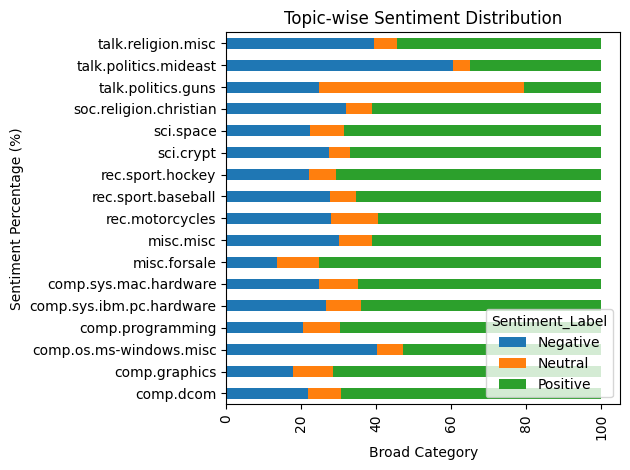

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# Create percentage table
topic_sentiment_percent = pd.crosstab(
    df_results["Broad_Category"],
    df_results["Sentiment_Label"],
    normalize='index'
) * 100

# Create single stacked bar chart
plt.figure(figsize=(14,8))
topic_sentiment_percent.plot(kind='barh', stacked=True)

plt.xlabel("Broad Category")
plt.ylabel("Sentiment Percentage (%)")
plt.title("Topic-wise Sentiment Distribution")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

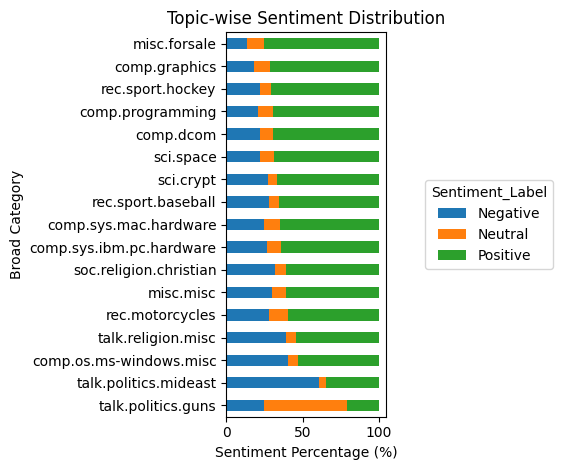

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Create percentage table
topic_sentiment_percent = pd.crosstab(
    df_results["Broad_Category"],
    df_results["Sentiment_Label"],
    normalize='index'
) * 100

# Sort categories by highest Positive %
topic_sentiment_percent = topic_sentiment_percent.sort_values(
    by="Positive",
    ascending=False
)

# Reverse row order for correct top display
topic_sentiment_percent = topic_sentiment_percent.iloc[::-1]

plt.figure(figsize=(14,8))
topic_sentiment_percent.plot(kind='barh', stacked=True)

plt.xlabel("Sentiment Percentage (%)")
plt.ylabel("Broad Category")
plt.title("Topic-wise Sentiment Distribution")

plt.legend(title="Sentiment_Label",
           loc="center left",
           bbox_to_anchor=(1.2, 0.5))

plt.tight_layout()
plt.show()

# themes and insights

In [56]:
import numpy as np

def get_top_words_per_topic(model, feature_names, n_top_words=8):
    topic_keywords = {}

    for topic_idx, topic in enumerate(model.components_):
        top_features = topic.argsort()[:-n_top_words - 1:-1]
        keywords = [feature_names[i] for i in top_features]
        topic_keywords[topic_idx] = keywords

    return topic_keywords

feature_names = tfidf_vectorizer.get_feature_names_out()

topic_keywords = get_top_words_per_topic(nmf_model, feature_names)

topic_keywords

{0: ['government',
  'state',
  'crime',
  'right',
  'weapon',
  'gun',
  'federal',
  'criminal'],
 1: ['window',
  'manager',
  'application',
  'running',
  'screen',
  'microsoft',
  'using',
  'font'],
 2: ['drive',
  'disk',
  'hard',
  'floppy',
  'boot',
  'jumper',
  'controller',
  'internal'],
 3: ['team', 'player', 'play', 'league', 'hockey', 'season', 'best', 'better'],
 4: ['thanks',
  'advance',
  'looking',
  'info',
  'anybody',
  'information',
  'appreciated',
  'help'],
 5: ['card',
  'video',
  'slot',
  'graphic',
  'nubus',
  'memory',
  'cache',
  'controller'],
 6: ['gebcadredslpittedu',
  'chastity',
  'njxp',
  'gordon',
  'shameful',
  'intellect',
  'skepticism',
  'surrender'],
 7: ['chip',
  'clipper',
  'encryption',
  'key',
  'algorithm',
  'escrow',
  'phone',
  'secure'],
 8: ['file',
  'directory',
  'format',
  'convert',
  'disk',
  'copy',
  'image',
  'utility'],
 9: ['armenian',
  'turkish',
  'armenia',
  'turkey',
  'turk',
  'genocide',
  '

In [57]:
topic_sentiment_percent = pd.crosstab(
    df_results["Broad_Category"],
    df_results["Sentiment_Label"],
    normalize='index'
) * 100

dominant_sentiment = topic_sentiment_percent.idxmax(axis=1)

dominant_sentiment

Broad_Category
comp.dcom                   Positive
comp.graphics               Positive
comp.os.ms-windows.misc     Positive
comp.programming            Positive
comp.sys.ibm.pc.hardware    Positive
comp.sys.mac.hardware       Positive
misc.forsale                Positive
misc.misc                   Positive
rec.motorcycles             Positive
rec.sport.baseball          Positive
rec.sport.hockey            Positive
sci.crypt                   Positive
sci.space                   Positive
soc.religion.christian      Positive
talk.politics.guns           Neutral
talk.politics.mideast       Negative
talk.religion.misc          Positive
dtype: str

In [58]:
topic_category_map = (
    df_results.groupby("Dominant_Topic")["Broad_Category"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

topic_category_map

{1: 'talk.politics.guns',
 2: 'comp.os.ms-windows.misc',
 3: 'comp.sys.ibm.pc.hardware',
 4: 'rec.sport.hockey',
 5: 'misc.misc',
 6: 'comp.graphics',
 7: 'misc.misc',
 8: 'sci.crypt',
 9: 'comp.sys.ibm.pc.hardware',
 10: 'talk.politics.mideast',
 11: 'misc.misc',
 12: 'misc.forsale',
 13: 'rec.motorcycles',
 14: 'comp.os.ms-windows.misc',
 15: 'soc.religion.christian',
 16: 'comp.sys.ibm.pc.hardware',
 17: 'talk.religion.misc',
 18: 'rec.sport.baseball',
 19: 'comp.graphics',
 20: 'talk.politics.mideast',
 21: 'comp.sys.mac.hardware',
 22: 'comp.programming',
 23: 'sci.space',
 24: 'comp.sys.ibm.pc.hardware',
 25: 'comp.sys.ibm.pc.hardware',
 26: 'rec.sport.baseball',
 27: 'comp.dcom',
 28: 'comp.dcom',
 29: 'comp.graphics',
 30: 'comp.dcom'}

In [59]:
used_topics = sorted(df_results["Dominant_Topic"].unique())

final_summary = []

for new_number, topic_idx in enumerate(used_topics, start=1):

    real_topic_idx = topic_idx - 1   # convert 1–30 → 0–29

    keywords = topic_keywords.get(real_topic_idx)
    category = topic_category_map.get(topic_idx)
    sentiment = dominant_sentiment.get(category, "Neutral")

    final_summary.append({
        "Topic_Number": new_number,
        "Original_Topic_ID": topic_idx,
        "Category": category,
        "Top_Keywords": ", ".join(keywords) if keywords else "",
        "Dominant_Sentiment": sentiment
    })

final_summary_df = pd.DataFrame(final_summary)
final_summary_df

,Topic_Number,Original_Topic_ID,Category,Top_Keywords,Dominant_Sentiment
0,1,1,talk.politics.guns,"government, state, crime, right, weapon, gun, ...",Neutral
1,2,2,comp.os.ms-windows.misc,"window, manager, application, running, screen,...",Positive
2,3,3,comp.sys.ibm.pc.hardware,"drive, disk, hard, floppy, boot, jumper, contr...",Positive
3,4,4,rec.sport.hockey,"team, player, play, league, hockey, season, be...",Positive
4,5,5,misc.misc,"thanks, advance, looking, info, anybody, infor...",Positive
5,6,6,comp.graphics,"card, video, slot, graphic, nubus, memory, cac...",Positive
6,7,7,misc.misc,"gebcadredslpittedu, chastity, njxp, gordon, sh...",Positive
7,8,8,sci.crypt,"chip, clipper, encryption, key, algorithm, esc...",Positive
8,9,9,comp.sys.ibm.pc.hardware,"file, directory, format, convert, disk, copy, ...",Positive
9,10,10,talk.politics.mideast,"armenian, turkish, armenia, turkey, turk, geno...",Negative


#summarization techniques

extractive summary

In [60]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def generate_topic_summary(topic_id, df, top_n_sentences=3):

    topic_docs = df[df["Dominant_Topic"] == topic_id]["Original_Text"]

    if len(topic_docs) == 0:
        return "No documents available for this topic."

    combined_text = " ".join(topic_docs)

    # --- CLEANING STEP ADDED HERE ---
    combined_text = re.sub(r'\S+@\S+', '', combined_text)  # remove emails
    combined_text = re.sub(r'[^a-zA-Z0-9.\s]', ' ', combined_text)  # remove special characters
    combined_text = re.sub(r'\s+', ' ', combined_text)  # remove extra spaces

    sentences = [s.strip() for s in combined_text.split(".")
                 if len(s.strip()) > 40 and not s.strip().isupper()]

    if len(sentences) <= top_n_sentences:
        return " ".join(sentences)

    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(sentences)

    sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()

    top_indices = sentence_scores.argsort()[-top_n_sentences:]
    top_indices = sorted(top_indices)

    summary = " ".join([sentences[i] for i in top_indices])

    return summary

In [61]:
topic_summaries = []

for topic_id in sorted(df_results["Dominant_Topic"].unique()):

    summary = generate_topic_summary(topic_id, df_results)

    topic_summaries.append({
        "Topic_ID": topic_id,
        "Summary": summary
    })

summary_df = pd.DataFrame(topic_summaries)
summary_df

,Topic_ID,Summary
0,1,At worst Koresh and his followers were innocen...
1,2,Does anyone have an idea where to look for the...
2,3,2 GIGabyte SCSI hard drive 1000 Quantum 240 ME...
3,4,MVP Candidates Name G AB H 2B 3B HR R RBI BB K...
4,5,I had no possibility to join the 7th annual X ...
5,6,FOR SALE Paradise SVGA accelerator card 800x60...
6,7,That is odd isn t it Why do you suppose it is ...
7,8,Adobe 1 415 961 0911 FAX info 1 800 235 0078 A...
8,9,X X We tend to dislike programs that X X are v...
9,10,Box 14571 Berkeley CA 94701 FAX 804 490 3832 E...


abstractive

In [1]:
import torch
torch.cuda.is_available()

False

In [3]:
# Core libraries
import torch
from transformers import pipeline
import gensim
import nltk
import sklearn

c:\Users\Computer\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
# import torch

# model_name = "facebook/bart-large-cnn"

# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# model = model.to("cpu")  # Move model to GPU

In [ ]:
# def generate_abstractive_summary(text, max_length=130):

#     inputs = tokenizer(
#         text,
#         max_length=1024,
#         truncation=True,
#         return_tensors="pt"
#     ).to("cuda")

#     summary_ids = model.generate(
#         inputs["input_ids"],
#         max_length=max_length,
#         min_length=30,
#         length_penalty=2.0,
#         num_beams=4,
#         early_stopping=True
#     )

#     summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

#     return summary

In [ ]:
text = "Artificial intelligence is transforming industries by enabling automation and data-driven decisions."
generate_abstractive_summary(text)

In [ ]:
# abstractive_summaries = []

# for index, row in summary_df.iterrows():  # assuming summary_df has all 30 topics
#     topic_id = row["Topic_ID"]
#     extractive_text = row["Summary"]

#     abs_summary = generate_abstractive_summary(extractive_text)  # GPU enabled

#     abstractive_summaries.append({
#         "Topic_ID": topic_id,
#         "Abstractive_Summary": abs_summary
#     })

# abstractive_df = pd.DataFrame(abstractive_summaries)
# abstractive_df

In [ ]:
# final_summary_df = summary_df.merge(abstractive_df, on="Topic_ID")
# final_summary_df.to_csv("final_topic_summaries_30.csv", index=False)

In [ ]:
# from google.colab import files
# files.download("final_topic_summaries_30.csv")

In [ ]:
import pandas as pd

df = pd.read_csv("final_topic_summaries_30.csv")
print(df[['Summary','Abstractive_Summary']].head())

# analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

In [2]:
# Load extractive + abstractive summaries
df_summaries = pd.read_csv("final_topic_summaries_30.csv")

# Check columns
print(df_summaries.columns)
df_summaries.head()

Index(['Topic_ID', 'Summary', 'Abstractive_Summary'], dtype='str')


,Topic_ID,Summary,Abstractive_Summary
0,1,At worst Koresh and his followers were innocen...,At worst Koresh and his followers were innocen...
1,2,Does anyone have an idea where to look for the...,Does anyone have an idea where to look for the...
2,3,2 GIGabyte SCSI hard drive 1000 Quantum 240 ME...,To discuss the purchase of any of these items ...
3,4,MVP Candidates Name G AB H 2B 3B HR R RBI BB K...,MVP Candidates Name G AB H 2B 3B HR R RBI BB K...
4,5,I had no possibility to join the 7th annual X ...,I had no possibility to join the 7th annual X ...


In [3]:
import pandas as pd

# Create mapping directly
data = {
    "Dominant_Topic": list(range(1,31)),
    "Topic_Label": [
        "Crime and Gun Control","Windows/Desktop Applications","Hard Disk and Storage Devices",
        "Hockey Discussion","General Help Requests","Graphics Hardware and Video Cards",
        "Random/Noisy Discussion","Cryptography and Encryption","File and Disk Utilities",
        "Armenia-Azerbaijan Conflict","General Discussion Posts","Product Sale and Marketplace",
        "Motorcycles and Riding","Software Troubleshooting","Christianity and Religion",
        "Device Drivers and Downloads","Casual Conversation","Baseball and Sports News",
        "Printing and Fonts","Middle East Conflict (Israel-Palestine)","Apple/Mac Video Hardware",
        "Program Errors and Debugging","Space and NASA Missions","SCSI and Data Interfaces",
        "Memory (VRAM/SIMMS) Issues","Sports Career and Statistics","Modems and Serial Communication",
        "Email and Mailing Lists","Graphics Software and Source Code","Telephone and Communication Services"
    ],
    "Broad_Category": [
        "talk.politics.guns","comp.os.ms-windows.misc","comp.sys.ibm.pc.hardware",
        "rec.sport.hockey","misc.misc","comp.graphics",
        "misc.misc","sci.crypt","comp.sys.ibm.pc.hardware",
        "talk.politics.mideast","misc.misc","misc.forsale",
        "rec.motorcycles","comp.os.ms-windows.misc","soc.religion.christian",
        "comp.sys.ibm.pc.hardware","talk.religion.misc","rec.sport.baseball",
        "comp.graphics","talk.politics.mideast","comp.sys.mac.hardware",
        "comp.programming","sci.space","comp.sys.ibm.pc.hardware",
        "comp.sys.ibm.pc.hardware","rec.sport.baseball","comp.dcom",
        "comp.dcom","comp.graphics","comp.dcom"
    ]
}

df_mapping = pd.DataFrame(data)
df_mapping.head()

,Dominant_Topic,Topic_Label,Broad_Category
0,1,Crime and Gun Control,talk.politics.guns
1,2,Windows/Desktop Applications,comp.os.ms-windows.misc
2,3,Hard Disk and Storage Devices,comp.sys.ibm.pc.hardware
3,4,Hockey Discussion,rec.sport.hockey
4,5,General Help Requests,misc.misc


In [4]:
import pandas as pd

# Raw sentiment counts for each category
data = {
    "Broad_Category": [
        "comp.dcom","comp.graphics","comp.os.ms-windows.misc","comp.programming",
        "comp.sys.ibm.pc.hardware","comp.sys.mac.hardware","misc.forsale","misc.misc",
        "rec.motorcycles","rec.sport.baseball","rec.sport.hockey","sci.crypt","sci.space",
        "soc.religion.christian","talk.politics.guns","talk.politics.mideast","talk.religion.misc"
    ],
    "Negative":[231,183,118,48,333,43,57,518,74,223,119,116,88,282,176,255,273],
    "Neutral":[91,109,20,23,116,18,47,154,33,55,40,24,36,61,391,19,44],
    "Positive":[732,731,155,163,801,112,319,1054,158,525,382,283,272,537,147,147,378]
}

df_sentiment = pd.DataFrame(data)
df_sentiment.set_index('Broad_Category', inplace=True)
df_sentiment.head()

,Negative,Neutral,Positive
Broad_Category,,,
comp.dcom,231,91,732
comp.graphics,183,109,731
comp.os.ms-windows.misc,118,20,155
comp.programming,48,23,163
comp.sys.ibm.pc.hardware,333,116,801


In [5]:
# Your 30-topic mapping
df_mapping = pd.DataFrame({
    "Dominant_Topic": list(range(1,31)),
    "Topic_Label": [
        "Crime and Gun Control","Windows/Desktop Applications","Hard Disk and Storage Devices",
        "Hockey Discussion","General Help Requests","Graphics Hardware and Video Cards",
        "Random/Noisy Discussion","Cryptography and Encryption","File and Disk Utilities",
        "Armenia-Azerbaijan Conflict","General Discussion Posts","Product Sale and Marketplace",
        "Motorcycles and Riding","Software Troubleshooting","Christianity and Religion",
        "Device Drivers and Downloads","Casual Conversation","Baseball and Sports News",
        "Printing and Fonts","Middle East Conflict (Israel-Palestine)","Apple/Mac Video Hardware",
        "Program Errors and Debugging","Space and NASA Missions","SCSI and Data Interfaces",
        "Memory (VRAM/SIMMS) Issues","Sports Career and Statistics","Modems and Serial Communication",
        "Email and Mailing Lists","Graphics Software and Source Code","Telephone and Communication Services"
    ],
    "Broad_Category": [
        "talk.politics.guns","comp.os.ms-windows.misc","comp.sys.ibm.pc.hardware",
        "rec.sport.hockey","misc.misc","comp.graphics","misc.misc","sci.crypt",
        "comp.sys.ibm.pc.hardware","talk.politics.mideast","misc.misc","misc.forsale",
        "rec.motorcycles","comp.os.ms-windows.misc","soc.religion.christian",
        "comp.sys.ibm.pc.hardware","talk.religion.misc","rec.sport.baseball",
        "comp.graphics","talk.politics.mideast","comp.sys.mac.hardware",
        "comp.programming","sci.space","comp.sys.ibm.pc.hardware",
        "comp.sys.ibm.pc.hardware","rec.sport.baseball","comp.dcom",
        "comp.dcom","comp.graphics","comp.dcom"
    ]
})

In [6]:
# Compute Dominant_Sentiment using max of Negative, Neutral, Positive
df_mapping['Dominant_Sentiment'] = df_mapping['Broad_Category'].map(
    df_sentiment[['Negative','Neutral','Positive']].idxmax(axis=1)
)

df_mapping[['Topic_Label','Broad_Category','Dominant_Sentiment']].head(30)

,Topic_Label,Broad_Category,Dominant_Sentiment
0,Crime and Gun Control,talk.politics.guns,Neutral
1,Windows/Desktop Applications,comp.os.ms-windows.misc,Positive
2,Hard Disk and Storage Devices,comp.sys.ibm.pc.hardware,Positive
3,Hockey Discussion,rec.sport.hockey,Positive
4,General Help Requests,misc.misc,Positive
5,Graphics Hardware and Video Cards,comp.graphics,Positive
6,Random/Noisy Discussion,misc.misc,Positive
7,Cryptography and Encryption,sci.crypt,Positive
8,File and Disk Utilities,comp.sys.ibm.pc.hardware,Positive
9,Armenia-Azerbaijan Conflict,talk.politics.mideast,Negative


In [7]:
df_summaries = df_summaries.merge(
    df_mapping[['Dominant_Topic','Topic_Label']],
    left_on='Topic_ID',
    right_on='Dominant_Topic',
    how='left'
)
df_summaries.drop(columns=['Dominant_Topic'], inplace=True)

In [8]:
df_summaries = df_summaries.merge(
    df_mapping[['Topic_Label','Dominant_Sentiment']],
    on='Topic_Label',
    how='left'
)

# Reorder columns
df_summaries = df_summaries[['Topic_ID','Topic_Label','Summary','Abstractive_Summary','Dominant_Sentiment']]

In [9]:
df_summaries.head(10)

,Topic_ID,Topic_Label,Summary,Abstractive_Summary,Dominant_Sentiment
0,1,Crime and Gun Control,At worst Koresh and his followers were innocen...,At worst Koresh and his followers were innocen...,Neutral
1,2,Windows/Desktop Applications,Does anyone have an idea where to look for the...,Does anyone have an idea where to look for the...,Positive
2,3,Hard Disk and Storage Devices,2 GIGabyte SCSI hard drive 1000 Quantum 240 ME...,To discuss the purchase of any of these items ...,Positive
3,4,Hockey Discussion,MVP Candidates Name G AB H 2B 3B HR R RBI BB K...,MVP Candidates Name G AB H 2B 3B HR R RBI BB K...,Positive
4,5,General Help Requests,I had no possibility to join the 7th annual X ...,I had no possibility to join the 7th annual X ...,Positive
5,6,Graphics Hardware and Video Cards,FOR SALE Paradise SVGA accelerator card 800x60...,FOR SALE Paradise SVGA accelerator card 800x60...,Positive
6,7,Random/Noisy Discussion,That is odd isn t it Why do you suppose it is ...,Skepticism is the chastity of the intellect an...,Positive
7,8,Cryptography and Encryption,Adobe 1 415 961 0911 FAX info 1 800 235 0078 A...,What is cryptology and how does one go about c...,Positive
8,9,File and Disk Utilities,X X We tend to dislike programs that X X are v...,X X We tend to dislike programs that X X are v...,Positive
9,10,Armenia-Azerbaijan Conflict,Box 14571 Berkeley CA 94701 FAX 804 490 3832 E...,60 REFUGEES FROM KELBAJAR PERISHED IN THEIR ES...,Negative


In [10]:
df_summaries.to_csv("Week5_Final_Report.csv", index=False)

C:\Users\Computer\AppData\Local\Temp\ipykernel_4344\3143932497.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_summaries, x='Dominant_Sentiment', palette='Set2')


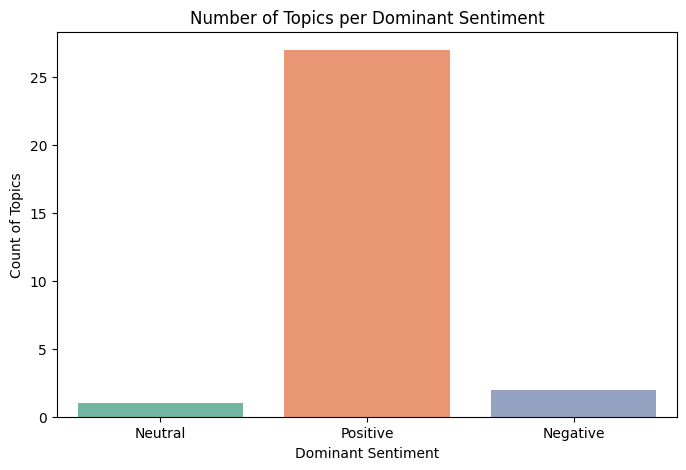

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df_summaries, x='Dominant_Sentiment', palette='Set2')
plt.title("Number of Topics per Dominant Sentiment")
plt.xlabel("Dominant Sentiment")
plt.ylabel("Count of Topics")
plt.show()

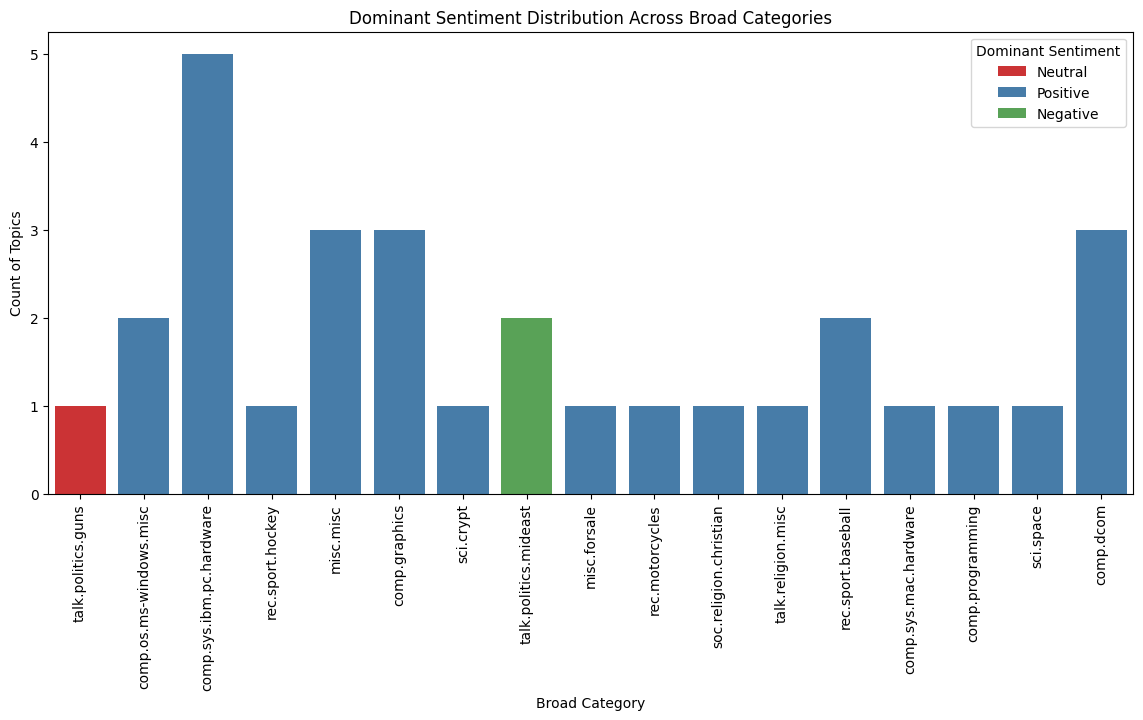

In [12]:
df_viz = df_summaries.merge(df_mapping[['Topic_Label','Broad_Category']], on='Topic_Label', how='left')

plt.figure(figsize=(14,6))
sns.countplot(data=df_viz, x='Broad_Category', hue='Dominant_Sentiment', palette='Set1')
plt.xticks(rotation=90)
plt.title("Dominant Sentiment Distribution Across Broad Categories")
plt.xlabel("Broad Category")
plt.ylabel("Count of Topics")
plt.legend(title='Dominant Sentiment')
plt.show()

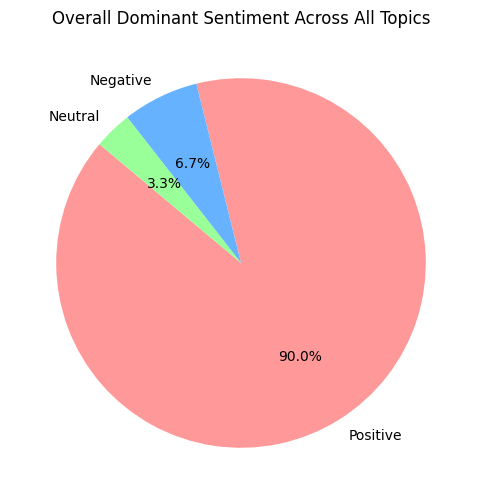

In [13]:
# Count how many topics fall under each dominant sentiment
sentiment_counts = df_summaries['Dominant_Sentiment'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
colors = ['#FF9999','#66B2FF','#99FF99']  # Red, Blue, Green for Negative, Neutral, Positive
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)
plt.title("Overall Dominant Sentiment Across All Topics")
plt.show()

In [1]:
# Run this in your notebook to save it as CSV
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

dataset = fetch_20newsgroups(remove=('headers','footers','quotes'))
df = pd.DataFrame({'text': dataset.data})
df.to_csv('newsgroups.csv', index=False)